# NeoMME on images: digits and hot dogs

> Train sysone's multimodal application on 100 MNIST digits (a choice) and 80 food photos (a noul), and look at what it gets right and wrong.

- skip_exec: true
- skip_showdoc: true

sysone's multimodal application answers typed questions about images with [NeoMME-260M](https://huggingface.co/Hcompany/NeoMME-260M), a bidirectional encoder of text and page images. This tutorial trains it on two small tasks and looks at each step on the way: the records, the rows the encoder reads, the training, the answers, and where they go wrong.

- **Digits**, a `choice` question. *Which digit is written in the image?* has ten options. There are 10 MNIST images of each digit to train on, and 10 others of each digit to score.
- **Hot dog, not hot dog**, a `noul` (a statement the model judges true or false). The statement is *The photo shows a hot dog.* There are 40 photos of each class to train on, and 40 others of each class to score.

On both tasks it compares three ways to train: the application's default head on the frozen encoder, a linear head fitted by LBFGS, and LoRA adapters that also train the encoder. The [multimodal](../20_neomme.ipynb) notebook explains how NeoMME's rows are built. This one uses the application the way a user would.

::: {.callout-note title="Running this notebook"}
The test suite skips this notebook (`skip_exec`). It downloads NeoMME-260M (526 MB, Apache-2.0) and the two datasets from the Hugging Face Hub; after that, the whole run takes about nine minutes. The outputs below come from a run on 2026-09-27 on an M3 Pro (MPS, fp32). A CUDA GPU is faster and a CPU is several times slower. It needs the `multimodal` and `plots` extras (`pip install "sysone[multimodal,plots]"`), and it saves its images in `neomme-images/`, next to the notebook.
:::

```{mermaid}
flowchart LR
    R["a record: an image path,<br/>a question, the gold answer"] --> T["the Image transform:<br/>load and resize"]
    T --> W["a row: the question, an anchor<br/>before each option, the image<br/>as a grid of patches"]
    W --> E["NeoMME-260M,<br/>frozen or with LoRA"]
    E --> A["a vector at<br/>each anchor"]
    A --> S["the head: standardise,<br/>score each anchor"]
    S --> P["÷ temperature,<br/>softmax"]
    P --> J["the answer:<br/>choice or noul"]
```

In [ ]:
import gc, io, json, logging, random, shutil, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea
from matplotlib.patches import Rectangle
from matplotlib_inline.backend_inline import set_matplotlib_formats
from PIL import Image as PILImage
from IPython.display import Image as DisplayImage, display
import datasets, huggingface_hub, transformers
from huggingface_hub import snapshot_download
from transformers.trainer_callback import PrinterCallback, ProgressCallback
from sysone.core import collate
from sysone.data import TypedDecisions
from sysone.losses import answer_metrics
from sysone.multimodal import decision_learner

In [ ]:
logging.getLogger("transformers").setLevel(logging.ERROR)
datasets.logging.set_verbosity_error(); huggingface_hub.utils.logging.set_verbosity_error()
datasets.disable_progress_bars(); transformers.utils.logging.disable_progress_bar()
set_matplotlib_formats("png"); plt.rcParams["figure.dpi"] = 110          # plain PNG plots, a third the size of retina ones
data_dir = Path("neomme-images")          # the images this notebook saves
t_start = time.time()
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"torch {torch.__version__} · transformers {transformers.__version__} · {device}")

torch 2.14.0 · transformers 5.17.0 · mps


Three small helpers. `quiet` removes the Trainer's printer, which would otherwise print a line of logs every ten steps. `learn.recorder` still keeps those numbers for the plots. Each learner holds its own copy of NeoMME, so the notebook deletes a learner once it's done with it, and `release` hands the memory back. `metrics` picks the numbers worth a look out of `validate`.

In [ ]:
def quiet(learn):
    "The learner, without the Trainer's per-step log lines in the outputs (`learn.recorder` still has them)"
    for cb in (PrinterCallback, ProgressCallback): learn.trainer.remove_callback(cb)
    return learn

def release():
    "Hand back the memory of deleted learners"
    gc.collect()
    if torch.backends.mps.is_available(): torch.mps.empty_cache()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def metrics(learn):
    "The held-out metrics worth a look, rounded"
    return {k: round(v, 3) for k, v in learn.validate().items() if k in ("accuracy", "soft_accuracy", "brier", "ece", "n")}

The plotting code is folded, since none of it is sysone's API. `show_cards` draws the prediction cards. Each card shows an image, the probability the model gave its gold label, where that label ranks, and the model's most likely labels as bars.

In [ ]:
#| code-fold: true
#| code-summary: plotting helpers
BLUE, LIGHT, TRACK, CARD, INK, GRAY = "#3b3ff5", "#9a9df7", "#d4d4d4", "#f2f2f2", "#111111", "#6b6b6b"

def show_figure(fig, fmt="png", dpi=90):
    "Display a figure as PNG, or as JPEG for photos, and close it"
    buf = io.BytesIO()
    fig.savefig(buf, format=fmt, dpi=dpi, **({"pil_kwargs": {"quality": 85}} if fmt == "jpeg" else {})); plt.close(fig)
    display(DisplayImage(buf.getvalue(), format=fmt))

def _line(ax, x, y, parts, size):
    "Pieces of text in their own weight and colour on one line, its top left corner at (x, y) in axes fraction"
    box = HPacker(children=[TextArea(s, textprops=dict(size=size, **kw)) for s, kw in parts], sep=size * 0.35, pad=0, align="baseline")
    ax.add_artist(AnchoredOffsetbox("upper left", child=box, bbox_to_anchor=(x, y), bbox_transform=ax.transAxes,
                                    frameon=False, pad=0, borderpad=0))

def square(im):
    "The centre square of a PIL image"
    w, h = im.size; s = min(w, h)
    return im.crop(((w - s) // 2, (h - s) // 2, (w - s) // 2 + s, (h - s) // 2 + s))

def _card(sf, image, gold, probs, top):
    "One card: the image, the gold label's probability and rank, and the most likely labels as bars"
    sf.set_facecolor(CARD)
    order = sorted(probs, key=probs.get, reverse=True)
    head = sf.add_axes([0.03, 0.84, 0.94, 0.12]); head.axis("off")
    _line(head, 0, 1, [(f"{gold} ({probs[gold]:.1%})", dict(weight="bold", color=INK)),
                       (f"Ranked {order.index(gold) + 1} out of {len(order)} labels", dict(color=GRAY))], 13)
    im = square(PILImage.open(image))
    ax = sf.add_axes([0.03, 0.06, 0.34, 0.74]); ax.axis("off")
    ax.imshow(im, cmap="gray" if im.mode == "L" else None, interpolation="nearest" if im.size[0] < 64 else "antialiased")
    bars = sf.add_axes([0.41, 0.06, 0.56, 0.74]); bars.axis("off"); bars.set_xlim(0, 1); bars.set_ylim(0, 1)
    for i, lab in enumerate(order[:top]):
        y, ok = 1 - i / 5, lab == gold
        bars.add_patch(Rectangle((0, y - 0.08), 1, 0.06, color=TRACK, lw=0))
        bars.add_patch(Rectangle((0, y - 0.08), max(probs[lab], 0.004), 0.06, color=BLUE if i == 0 else LIGHT, lw=0))
        _line(bars, 0, y - 0.11, [("✓" if ok else "✕", dict(color=INK if ok else GRAY)),
                                  (lab, dict(weight="bold", color=INK if ok else GRAY))], 11.5)

def show_cards(cards, ncols=2, top=5, fmt="png"):
    "Prediction cards in a grid, each a dict of an image path, the gold label and every label's probability"
    nrows = -(-len(cards) // ncols)
    fig = plt.figure(figsize=(6.2 * ncols, 2.8 * nrows))
    sfs = np.atleast_1d(fig.subfigures(nrows, ncols, wspace=0.02, hspace=0.04)).ravel()
    for sf, c in zip(sfs, cards): _card(sf, c["image"], c["gold"], c["probs"], top)
    for sf in sfs[len(cards):]: sf.set_facecolor("white")
    show_figure(fig, fmt)

def plot_history(learn, title, chance):
    "The training loss at every logged step, and the held-out loss and accuracy after every epoch"
    ms, tr = learn.recorder.metrics, learn.recorder.losses
    ep = [m["epoch"] for m in ms]; x = np.linspace(ep[-1] / len(tr), ep[-1], len(tr))
    fig, (a, b) = plt.subplots(1, 2, figsize=(10, 2.8))
    a.plot(x, tr, color="gray", lw=1, label="training rows"); a.plot(ep, [m["loss"] for m in ms], color="C0", lw=1.5, label="held-out rows")
    a.set(xlabel="epoch", ylabel="loss (soft CE)"); a.legend(frameon=False)
    b.plot(ep, [m["accuracy"] for m in ms], color="C0", lw=1.5); b.axhline(chance, ls="--", color="gray", lw=1)
    b.text(ep[-1], chance + 0.02, "chance", ha="right", va="bottom", color="gray", fontsize=9)
    b.set(xlabel="epoch", ylabel="held-out accuracy", ylim=(0, 1)); fig.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()

def plot_confusion(panels, labels):
    "A confusion matrix per model: a row per gold label, a column per answer"
    fig, axs = plt.subplots(1, len(panels), figsize=(3.4 * len(panels), 3.4), squeeze=False)
    for ax, (name, (gold, pred)) in zip(axs[0], panels.items()):
        M = np.zeros((len(labels), len(labels)), int)
        for g, p in zip(gold, pred): M[labels.index(g), labels.index(p)] += 1
        top = M.sum() / len(labels)
        ax.imshow(M, cmap="Blues", vmin=0, vmax=top)
        for (r, c), v in np.ndenumerate(M):
            if v: ax.text(c, r, v, ha="center", va="center", fontsize=8, color="white" if v > top / 2 else INK)
        ax.set(xticks=range(len(labels)), yticks=range(len(labels)), xlabel="answer", ylabel="gold")
        ax.set_xticklabels(labels, fontsize=8); ax.set_yticklabels(labels, fontsize=8)
        ax.set_title(f"{name}: accuracy {np.trace(M) / M.sum():.2f}", fontsize=10)
    plt.tight_layout(); plt.show()

def show_grid(img, h, w, p=32, title="", fmt="png"):
    "An image with its grid of p-pixel patches drawn over it"
    fig, ax = plt.subplots(figsize=(0.45 * w + 0.4, 0.45 * h + 0.6))
    ax.imshow(img, interpolation="nearest")
    for r in range(1, h): ax.axhline(r * p - 0.5, color="C1", lw=0.8)
    for c in range(1, w): ax.axvline(c * p - 0.5, color="C1", lw=0.8)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, fontsize=10)
    show_figure(fig, fmt, dpi=110)

## Digits: a choice question

MNIST's digits are 28 × 28 grey images. A state is JSON, so an image travels as a file path. `mnist_records` goes through each MNIST split in a seeded random order and keeps the first 10 images of each digit: 100 from the train split and 100 from the test split. It saves them as PNG files and builds one record per image, holding the question and the gold answer. Because the order is seeded, every run draws the same images.

In [ ]:
def mnist_records(per_class=10, seed=0, dest=data_dir / "mnist"):
    "Choice records over MNIST: `per_class` images of each digit from its train split, and as many from its test split"
    rng, ds = random.Random(seed), datasets.load_dataset("ylecun/mnist")
    q = {"digit": {"type": "choice", "instructions": "Which digit is written in the image?", "criteria": [str(d) for d in range(10)]}}
    out = {}
    for split in ("train", "test"):
        labels, by = ds[split]["label"], {d: [] for d in range(10)}
        for i in rng.sample(range(len(labels)), len(labels)):
            if len(by[labels[i]]) < per_class: by[labels[i]].append(i)
            if all(len(v) == per_class for v in by.values()): break
        (dest / split).mkdir(parents=True, exist_ok=True); out[split] = []
        for d, idx in by.items():
            for i in idx:
                p = dest / split / f"{i}.png"
                if not p.exists(): ds[split][i]["image"].save(p)     # saved once: the feature cache keys on each file's size and time
                out[split].append({"id": f"mnist-{split}-{i}", "state": {"text": "", "image": str(p)}, "questions": q,
                                   "gold": {"digit": {"label": str(d)}}})
        rng.shuffle(out[split])
    return out["train"], out["test"]

train, test = mnist_records()
print(len(train), "cases to train on,", len(test), "to score")
print(json.dumps(train[0], indent=1))

100 cases to train on, 100 to score
{
 "id": "mnist-train-27562",
 "state": {
  "text": "",
  "image": "neomme-images/mnist/train/27562.png"
 },
 "questions": {
  "digit": {
   "type": "choice",
   "instructions": "Which digit is written in the image?",
   "criteria": [
    "0",
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9"
   ]
  }
 },
 "gold": {
  "digit": {
   "label": "8"
  }
 }
}


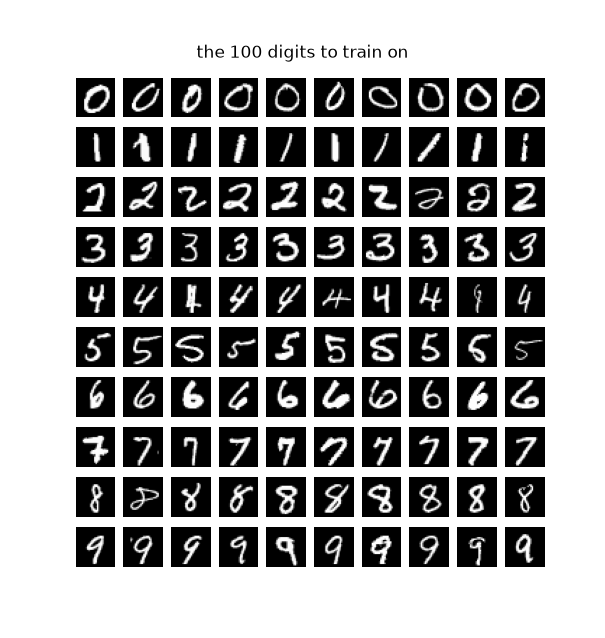

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, axs = plt.subplots(10, 10, figsize=(5.5, 5.8))
for d in range(10):
    for j, r in enumerate(r for r in train if r["gold"]["digit"]["label"] == str(d)):
        axs[d, j].imshow(PILImage.open(r["state"]["image"]), cmap="gray"); axs[d, j].axis("off")
fig.suptitle("the 100 digits to train on", y=0.93, fontsize=11); show_figure(fig, dpi=110)

### A learner, and what it reads

`TypedDecisions.from_records` takes the cases to train on and the cases to score (`valid`), and holds out a fifth of the training cases (`calib=0.2`) to fit the temperatures. `decision_learner` then:

- binds the records to NeoMME's tokenizer and image processor;
- adds the `Image` transform, which loads each state's image and resizes it so its long side is `image_side` pixels;
- loads the encoder and builds the head.

With `train="head"` the encoder stays frozen, and its vectors at the anchors are cached, so the head trains on stored vectors.

In [ ]:
data = TypedDecisions.from_records(train, valid=test, calib=0.2)
torch.manual_seed(0)
learn = quiet(decision_learner(data, "Hcompany/NeoMME-260M", train="head", image_side=224))
learn

Learner(Hcompany/NeoMME-260M · regime head · head 0 layers/laya · cache masks · loss soft_ce · 1,055,745 of 263,993,651 params train)

Each case becomes one row per question. `show_batch` prints a training row as the encoder reads it, with runs of image tokens counted:

In [ ]:
learn.show_batch(1)

<doc> choice question: Which digit is written in the image? <mask> 0 <mask> 1 <mask> 2 <mask> 3 <mask> 4 <mask> 5 <mask> 6 <mask> 7 <mask> 8 <mask> 9 <doc> <img>×8 <row> <img>×7 <row> <img>×7 <row> <img>×7 <row> <img>×7 <row> <img>×7 <row> <img>×7 <row>
markers [12, 15, 18, 21, 24, 27, 30, 33, 36, 39] · qtype choice · 100 tokens



The row opens with the question. Then come the ten options, each after a `<mask>`, the anchor where the head reads that option's vector. The image follows as a block: `<doc>`, then `<img>`, then one `<img>` per 32-pixel patch, with a `<row>` closing each row of the grid. At 224 pixels a digit is a 7 × 7 grid of 49 patches. NeoMME's processor pads the image with black to a multiple of 32 pixels and cuts it into patches. Putting the patches back together shows exactly what the encoder receives:

7 rows of 7 patches: 49 patches, and 58 of the row's 100 tokens


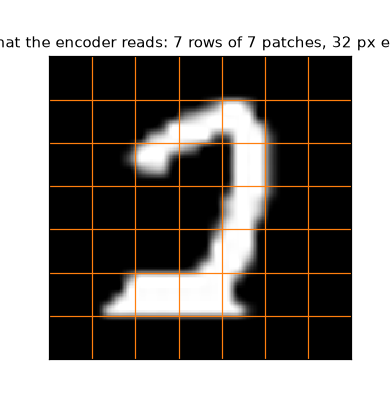

In [ ]:
def row_image(learn, split="train", i=0):
    "The image of a row, put back together from its patches; its grid; the row's length"
    row, ip, tok = learn.data.lazy_rows(split)[i], learn.data.builder.processor.image_processor, learn.data.builder.tok
    ids, p = np.asarray(row["input_ids"]), ip.patch_size
    h = int((ids == tok.row_token_id).sum()); w = len(row["pixel_values"]) // h
    x = row["pixel_values"].reshape(h, w, p, p, 3).permute(0, 2, 1, 3, 4).reshape(h * p, w * p, 3)
    return (x * torch.tensor(ip.image_std) + torch.tensor(ip.image_mean)).clamp(0, 1).numpy(), h, w, len(ids)

img, h, w, n = row_image(learn)
print(f"{h} rows of {w} patches: {h * w} patches, and {h * w + h + 2} of the row's {n} tokens")
show_grid(img, h, w, title=f"what the encoder reads: {h} rows of {w} patches, 32 px each")

### Training the head

The encoder runs once over every row, and the anchor vectors are stored (in `~/.cache/sysone/features`, so a second run of the notebook skips this):

In [ ]:
t0 = time.time()
for split in ("train", "calib", "valid"): learn.dataset(split)
print(f"the anchors of {sum(len(learn.dataset(s)) for s in ('train', 'calib', 'valid'))} rows, cached in {time.time() - t0:.0f} s")

the anchors of 200 rows, cached in 4 s


The application's default head is Laya's scorer on the anchors: a LayerNorm, a 1,024 × 1,024 layer, a GELU and a layer down to one score per anchor. That is about a million weights, with 80 examples to learn them from. `lr_find` runs the learning-rate range test:

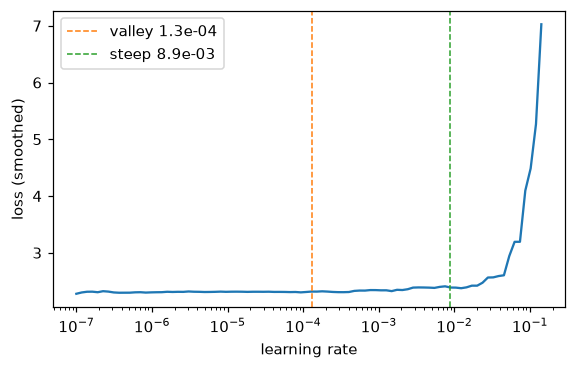

SuggestedLRs(valley=1.29e-04, steep=8.90e-03)

In [ ]:
sugg = learn.lr_find()
learn.plot_lr_find(sugg); plt.show()
sugg

On 80 examples the range test says little. Over its 100 steps the loss stays flat until the rate is high enough to make it climb, and the valley it suggests is too cautious: in the [multimodal](../20_neomme.ipynb#two-small-image-tasks-on-the-real-checkpoint) notebook's runs, a head trained at the valley learned less than one trained at 10⁻³. So this one trains for 30 epochs at 10⁻³, with warmup and then cosine decay. After the fit, the learner fits a temperature on the calib split:

trained in 6.0 s; temperatures {'choice': 2.3453, 'choice:6-10': 2.3453}


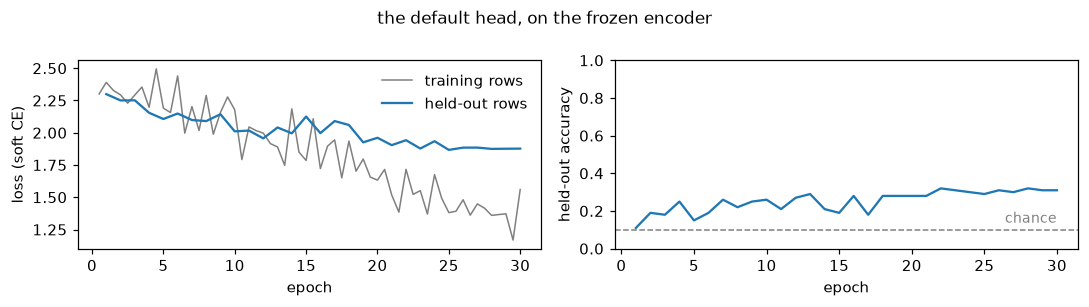

{'accuracy': 0.31,
 'soft_accuracy': 0.195,
 'brier': 0.78,
 'ece': 0.112,
 'n': 100}

In [ ]:
t0 = time.time()
learn.fit_one_cycle(30, lr=1e-3)
print(f"trained in {time.time() - t0:.1f} s; temperatures {learn.temperatures}")
plot_history(learn, "the default head, on the frozen encoder", chance=0.1)
metrics(learn)

`validate` scores the 100 held-out images with the fitted temperature. With 100 test images an accuracy is known to about ±0.05 (one standard error), so a difference of a few points is noise.

### The answers

`learn.decider()` answers in the Jev schema from the model in memory: the chosen option, every option's probability, and a confidence.

In [ ]:
q = test[0]["questions"]
answers = {"default head": learn.decider().predict_batch([r["state"] for r in test], q)}
print(json.dumps(answers["default head"][0], indent=1))
m = answer_metrics([(q, a, r["gold"]) for a, r in zip(answers["default head"], test)])
print("the answers' metrics:", {k: round(m[k], 3) for k in ("accuracy", "soft_accuracy", "brier", "ece")})

{
 "digit": {
  "type": "choice",
  "choice": "6",
  "probabilities": {
   "0": 0.0197,
   "1": 0.0306,
   "2": 0.1129,
   "3": 0.0891,
   "4": 0.1359,
   "5": 0.1258,
   "6": 0.1669,
   "7": 0.1192,
   "8": 0.0962,
   "9": 0.1038
  },
  "confidence": 0.0488,
  "answer_confidence": 0.1669
 }
}
the answers' metrics: {'accuracy': 0.31, 'soft_accuracy': 0.195, 'brier': 0.78, 'ece': 0.112}


The answers score what `validate` scored, because they are the same rows read through the inference path. Here is the first test image of each digit, with the probability the head gave the right digit and its five most likely digits:

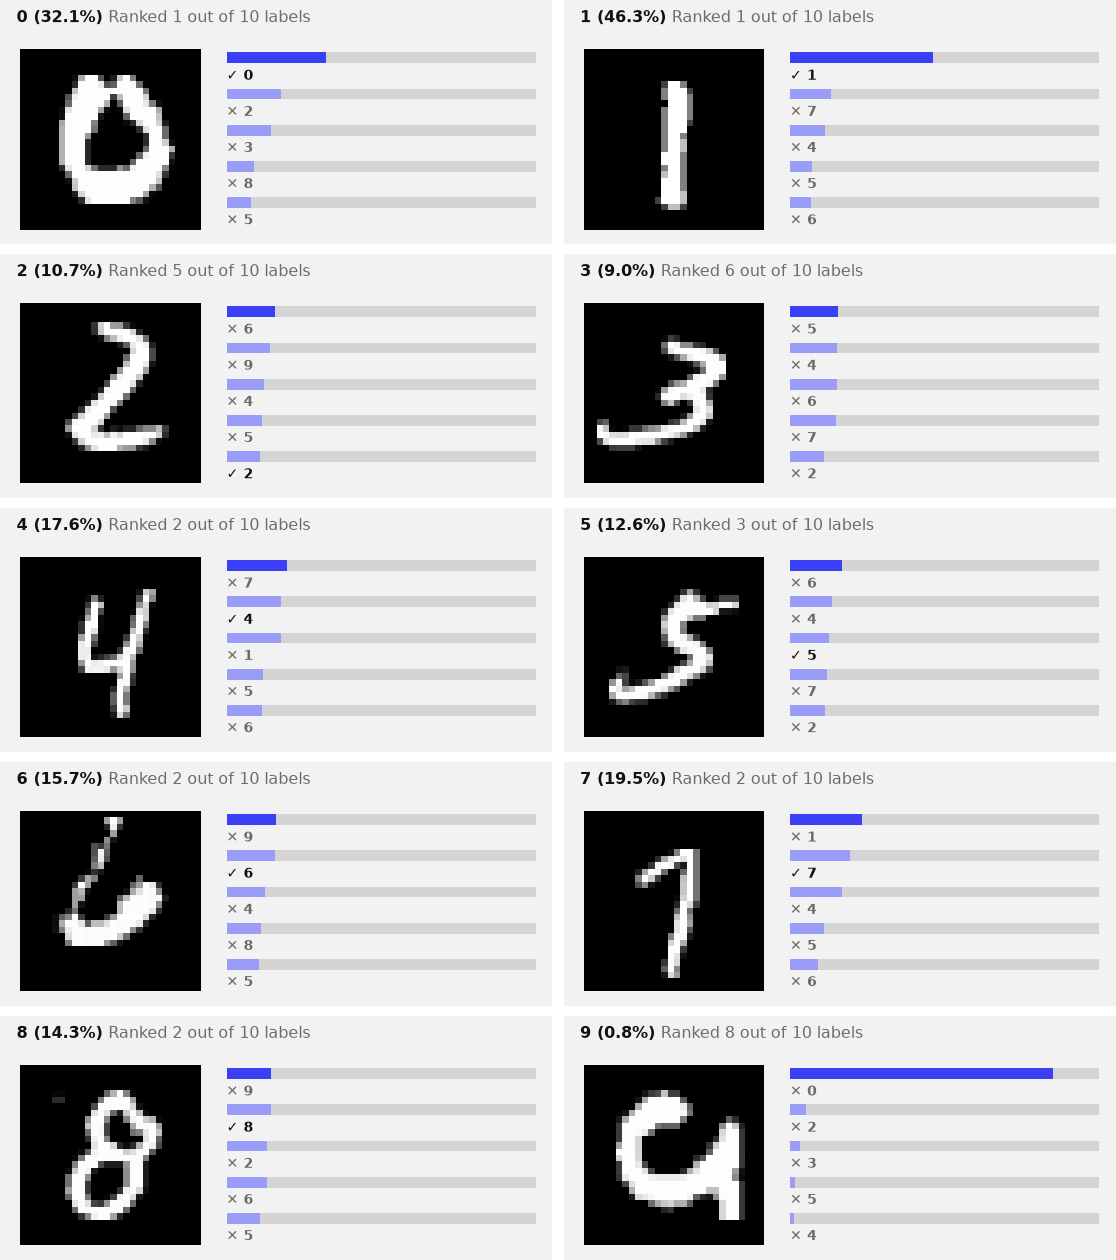

In [ ]:
def digit_cards(answers, recs):
    "A card per record: its image, its gold digit and every digit's probability"
    return [{"image": r["state"]["image"], "gold": r["gold"]["digit"]["label"], "probs": a["digit"]["probabilities"]}
            for a, r in zip(answers, recs)]

firsts = [next(i for i, r in enumerate(test) if r["gold"]["digit"]["label"] == str(d)) for d in range(10)]
show_cards(digit_cards([answers["default head"][i] for i in firsts], [test[i] for i in firsts]))

The head gets the 0 and the 1 right, and puts the right digit second for the 4, 6, 7 and 8. It misses the 2, the 3 and the 5 by more, and reads the 9 as a 0 with high confidence. Most of its probabilities are low, which suits a head that is right about three times in ten: the temperature fitted on the calib split, 2.3, spreads them out.

### Why the head standardises NeoMME's vectors

To see what the head works with, look at the anchor vectors it trains on: 80 training rows with 10 anchors each, every vector 1,024 wide.

In [ ]:
A = np.concatenate([np.asarray(a, dtype=np.float32) for a in learn.dataset("train")["anchors"]])
norm, mu, sd = np.linalg.norm(A, axis=1), A.mean(0), A.std(0)
c = int(np.abs(mu).argmax())
print(f"{A.shape[0]} vectors of width {A.shape[1]}, norm {norm.mean():.2f} ± {norm.std():.3f}")
print(f"channel {c}: mean {mu[c]:.2f}, sd {sd[c]:.3f}, {np.mean(np.abs(A[:, c]) / norm):.1%} of every vector's norm")
print(f"the other {A.shape[1] - 1} channels: |mean| at most {np.sort(np.abs(mu))[-2]:.2f}, sd at most {np.delete(sd, c).max():.3f}")

800 vectors of width 1024, norm 32.00 ± 0.000
channel 139: mean 30.87, sd 0.018, 96.5% of every vector's norm
the other 1023 channels: |mean| at most 1.26, sd at most 0.130


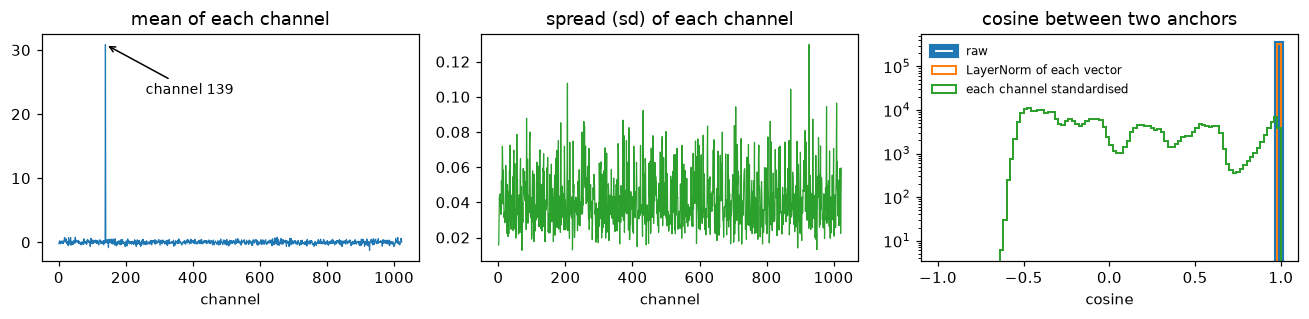

In [ ]:
#| code-fold: true
#| code-summary: figure code
def cosines(X):
    X = X / np.linalg.norm(X, axis=1, keepdims=True); C = X @ X.T
    return C[np.triu_indices(len(X), 1)]
layer_norm = lambda X: (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs[0].plot(mu, lw=0.8); axs[0].set(title="mean of each channel", xlabel="channel")
axs[0].annotate(f"channel {c}", (c, mu[c]), (c + 120, mu[c] * 0.75), arrowprops=dict(arrowstyle="->"), fontsize=9)
axs[1].plot(sd, lw=0.8, color="C2"); axs[1].set(title="spread (sd) of each channel", xlabel="channel")
for X, name, lw in ((A, "raw", 4), (layer_norm(A), "LayerNorm of each vector", 1.3), ((A - mu) / sd, "each channel standardised", 1.3)):
    axs[2].hist(cosines(X), bins=100, range=(-1, 1), histtype="step", lw=lw, label=name)
axs[2].set(title="cosine between two anchors", yscale="log", xlabel="cosine"); axs[2].legend(fontsize=8, frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

NeoMME's last layer is a norm without a learned scale, so every vector has the same length, √1024 = 32. Channel 139 holds 30.9 of it in every vector and barely moves from one vector to the next (its spread is 0.018). It carries almost all of each vector's length and almost nothing that tells two vectors apart, so any two anchors have a cosine above 0.99.

A LayerNorm doesn't change that. It centres and scales each vector by that vector's own mean and spread, and the same channel sets both, so the layer-normed cosines sit on top of the raw ones. Standardising each channel over the training vectors (subtract the channel's mean, divide by its spread) removes the constant and puts every channel on one scale, and the cosines spread out between −0.6 and 1. That's what `DecisionHead(standardize=True)` does. It fits the per-channel statistics on the training rows before the first fit, and the multimodal application turns it on.

The same channel is why the application caches the anchors in float32: float16's step near 30.9 is about as large as the channel's whole spread (see the finding in the [multimodal](../20_neomme.ipynb#a-head-only-run) notebook).

The same recipe, without the standardisation:

In [ ]:
torch.manual_seed(0)
raw = quiet(decision_learner(data, "Hcompany/NeoMME-260M", train="head", image_side=224, standardize=False))
raw.fit_one_cycle(30, lr=1e-3)
print(f"accuracy without standardising: {raw.validate()['accuracy']:.2f}, with: {learn.validate()['accuracy']:.2f}")
del raw; release()

accuracy without standardising: 0.14, with: 0.31


### The linear head

`head="linear"` scores every anchor with a single weight vector. `fit_linear` fits it on the cached anchors by LBFGS. The problem is convex, with one optimum, so there's no learning rate or number of epochs to pick:

In [ ]:
torch.manual_seed(0)
lin = quiet(decision_learner(data, "Hcompany/NeoMME-260M", train="head", head="linear", image_side=224))
print(lin.fit_linear())
answers["linear head"] = lin.decider().predict_batch([r["state"] for r in test], q)
metrics(lin)

{'train_loss': 0.4460946023464203, 'seconds': 0.23}


{'accuracy': 0.41,
 'soft_accuracy': 0.292,
 'brier': 0.721,
 'ece': 0.169,
 'n': 100}

### What NeoMME's image representation holds

How much of the digit is in NeoMME's representation of the image, whatever the head does with it? A *probe* leaves out the question, the options and the head. It averages the encoder's output over the image's positions, giving one vector per image, and fits a logistic regression from those vectors to the digit on the 100 training images (the train and calib splits):

In [ ]:
def image_vectors(learn, split):
    "One vector per case: the mean of the encoder's output over the image's positions"
    model, tok, rows = learn.model.eval(), learn.data.builder.tok, learn.data.lazy_rows(split)
    X, y = [], []
    with torch.no_grad():
        for i in range(len(rows)):
            b = collate([rows[i]], tok.pad_token_id or 0).to(model.device)
            h = model.encode(b["input_ids"], b["attention_mask"], position_ids=b["position_ids"], pixel_values=b["pixel_values"])
            X.append(h[0, b["input_ids"][0] == tok.image_token_id].float().mean(0).cpu()); y.append(int(rows[i]["label"]))
    return torch.stack(X), torch.tensor(y)

def probe(Xtr, ytr, Xte, yte, l2=1e-3):
    "The test accuracy of a multinomial logistic regression on standardised features, fitted by LBFGS"
    mu, sd = Xtr.mean(0), Xtr.std(0).clamp_min(1e-6); Xtr, Xte = (Xtr - mu) / sd, (Xte - mu) / sd
    W = torch.zeros(Xtr.shape[1], int(ytr.max()) + 1, requires_grad=True); b = torch.zeros(W.shape[1], requires_grad=True)
    opt = torch.optim.LBFGS([W, b], max_iter=300, line_search_fn="strong_wolfe")
    def closure():
        opt.zero_grad(); loss = F.cross_entropy(Xtr @ W + b, ytr) + l2 * (W ** 2).sum(); loss.backward(); return loss
    opt.step(closure)
    return ((Xte @ W + b).argmax(-1) == yte).float().mean().item()

(Xa, ya), (Xb, yb), (Xv, yv) = (image_vectors(lin, s) for s in ("train", "calib", "valid"))
probes = {"digits": probe(torch.cat([Xa, Xb]), torch.cat([ya, yb]), Xv, yv)}
print(f"the probe on NeoMME's image vectors: {probes['digits']:.2f}")
pixels = lambda recs: torch.stack([torch.from_numpy(np.asarray(PILImage.open(r["state"]["image"]), dtype=np.float32).ravel() / 255) for r in recs])
digits = lambda recs: torch.tensor([int(r["gold"]["digit"]["label"]) for r in recs])
pixel_probe = probe(pixels(train), digits(train), pixels(test), digits(test))
print(f"the same regression on the 784 raw pixels: {pixel_probe:.2f}")
del learn, lin; release()

the probe on NeoMME's image vectors: 0.56
the same regression on the 784 raw pixels: 0.77


The probe reads 0.56 from the image vectors, more than either head reads from the anchors (0.31 and 0.41). The anchors sit on the options, and what they know about the image reaches them through attention. The raw pixels, at 0.77, beat everything. NeoMME was trained on pages, and a 28-pixel digit blown up to 224 pixels becomes 49 patches of blurred strokes. The [last section](#one-more-setting-the-image-size) measures how much of that is the size.

### LoRA: training the encoder too

`train="lora"` adds rank-8 LoRA adapters to the attention projections of NeoMME's 17 layers (`q_proj`, `k_proj`, `v_proj` and `o_proj`, 905,216 weights) and trains them together with the head. The encoder's outputs now change at every step, so there's no cache: every epoch runs the encoder over the 80 training rows. It trains for 20 epochs at 10⁻³:

Learner(Hcompany/NeoMME-260M · regime lora · head 0 layers/laya · cache None · loss soft_ce · 1,960,961 of 264,898,867 params train)
trained in 146 s; temperatures {'choice': 3.8516, 'choice:6-10': 3.8516}


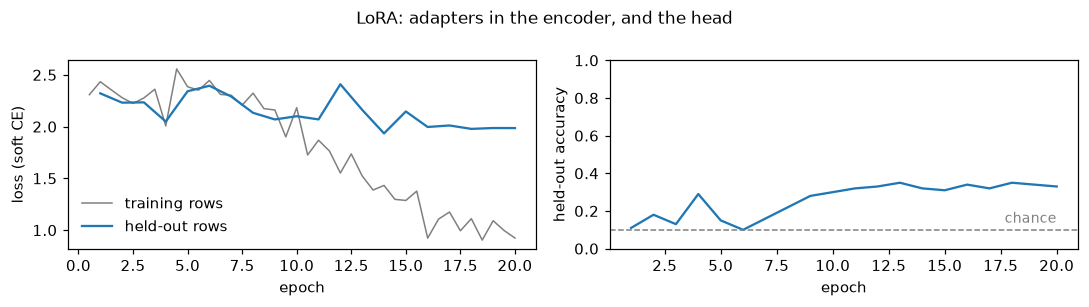

{'accuracy': 0.33,
 'soft_accuracy': 0.178,
 'brier': 0.787,
 'ece': 0.105,
 'n': 100}

In [ ]:
torch.manual_seed(0)
lora = quiet(decision_learner(data, "Hcompany/NeoMME-260M", train="lora", image_side=224))
print(lora)
t0 = time.time(); lora.fit_one_cycle(20, lr=1e-3)
print(f"trained in {time.time() - t0:.0f} s; temperatures {lora.temperatures}")
answers["LoRA"] = lora.decider().predict_batch([r["state"] for r in test], q)
plot_history(lora, "LoRA: adapters in the encoder, and the head", chance=0.1)
metrics(lora)

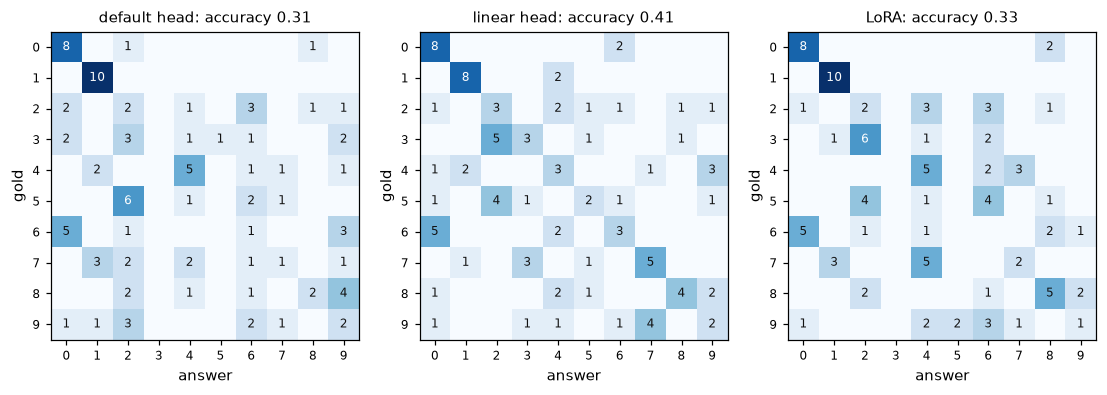

In [ ]:
del lora; release()
gold = [r["gold"]["digit"]["label"] for r in test]
plot_confusion({name: (gold, [a["digit"]["choice"] for a in ans]) for name, ans in answers.items()}, [str(d) for d in range(10)])

All three models read the 0s and the 1s (8 to 10 of 10 each) and confuse most of the rest. All three send half the 6s to 0, and neither the default head nor LoRA ever answers 3. LoRA trains 1.96 million weights (the attention adapters and the head), yet it does no better than the linear head's single weight vector on the frozen encoder: 80 images are few for that many weights. LoRA's result also moves between runs, because training through the encoder on MPS isn't bit-for-bit repeatable. Four runs of this LoRA fit gave between 0.32 and 0.36 on the digits, while the heads' accuracies repeat from one run to the next.

## Hot dog, not hot dog: a noul

A noul reads as two anchors, one for *false* and one for *true*. Its answer is the probability that the statement is true. The photos come from [truepositive/hotdog_nothotdog](https://huggingface.co/datasets/truepositive/hotdog_nothotdog) on the Hugging Face Hub: its train split holds 100 stock photos of hot dogs and 100 of other food, each 224 pixels on its long side. It stands in for Kaggle's [dansbecker/hot-dog-not-hot-dog](https://www.kaggle.com/datasets/dansbecker/hot-dog-not-hot-dog), which needs a Kaggle account to download; [the last section](#with-kaggles-photos) shows how to run on Kaggle's copy. `hotdog_records` shuffles each class with a seed, then takes 40 photos to train on and 40 others to score. It copies them next to the notebook, so the records hold short relative paths.

In [ ]:
def hotdog_records(per_class=40, seed=0, src=None, dest=data_dir / "hotdog"):
    "Noul records over photos of hot dogs and of other food: `per_class` of each class to train on, `per_class` others to score"
    src = Path(src or snapshot_download("truepositive/hotdog_nothotdog", repo_type="dataset"))
    rng, q, train, test = random.Random(seed), {"hot_dog": {"type": "noul", "instructions": "The photo shows a hot dog."}}, [], []
    for cls, truth in (("hotdog", 1.0), ("not_hotdog", 0.0)):
        folder = next(p for p in sorted(src.rglob("*")) if p.is_dir() and p.parent.name == "train"
                      and p.name.replace("_", "") == cls.replace("_", ""))           # hotdog or hot_dog, not_hotdog or not_hot_dog
        files = sorted(folder.glob("*.jpg")); rng.shuffle(files)
        (dest / cls).mkdir(parents=True, exist_ok=True)
        for part, fs in ((train, files[:per_class]), (test, files[per_class:2 * per_class])):
            for f in fs:
                p = dest / cls / f.name
                if not p.exists(): shutil.copy2(f, p)                            # the copy keeps the file's time, which the cache keys on
                part.append({"id": f"{cls}-{f.stem}", "state": {"text": "", "image": str(p)}, "questions": q,
                             "gold": {"hot_dog": {"noul": truth}}})
    rng.shuffle(train); rng.shuffle(test)
    return train, test

htrain, htest = hotdog_records()
print(len(htrain), "cases to train on,", len(htest), "to score")
print(json.dumps(htrain[0], indent=1))

80 cases to train on, 80 to score
{
 "id": "hotdog-4518648",
 "state": {
  "text": "",
  "image": "neomme-images/hotdog/hotdog/4518648.jpg"
 },
 "questions": {
  "hot_dog": {
   "type": "noul",
   "instructions": "The photo shows a hot dog."
  }
 },
 "gold": {
  "hot_dog": {
   "noul": 1.0
  }
 }
}


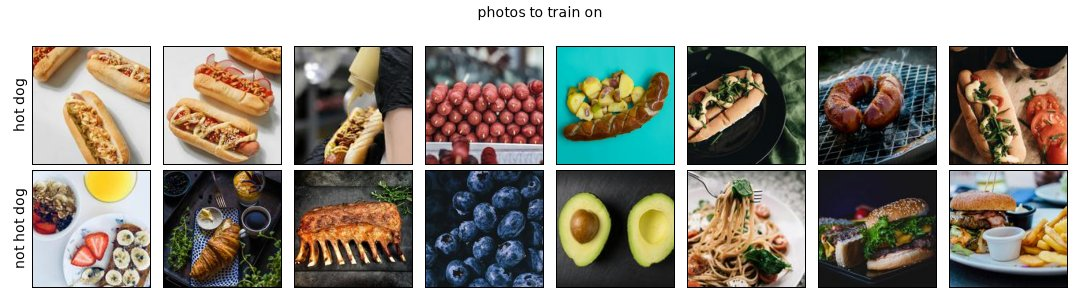

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, axs = plt.subplots(2, 8, figsize=(12, 3.4))
for row, (truth, name) in enumerate(((1.0, "hot dog"), (0.0, "not hot dog"))):
    for ax, r in zip(axs[row], [r for r in htrain if r["gold"]["hot_dog"]["noul"] == truth][:8]):
        ax.imshow(square(PILImage.open(r["state"]["image"]))); ax.set_xticks([]); ax.set_yticks([])
    axs[row, 0].set_ylabel(name, fontsize=11)
fig.suptitle("photos to train on", fontsize=11); plt.tight_layout(); show_figure(fig, "jpeg")

The photos are enlarged to 384 pixels on their long side (`image_side=384`). Most of them are 3:2, landscape or portrait, which at 384 pixels makes 96 patches: 12 along the long side and 8 along the short one.

<doc> noul question: The photo shows a hot dog. <mask> false: no, the statement does not hold <mask> true: yes, the statement holds <doc> <img>×9 <row> <img>×8 <row> <img>×8 <row> <img>×8 <row> <img>× … w> <img>×8 <row> <img>×8 <row> <img>×8 <row> <img>×8 <row> <img>×8 <row> <img>×8 <row> <img>×8 <row>
markers [12, 21] · qtype noul · 139 tokens

12 rows of 8 patches: 96 patches, and 110 of the row's 139 tokens


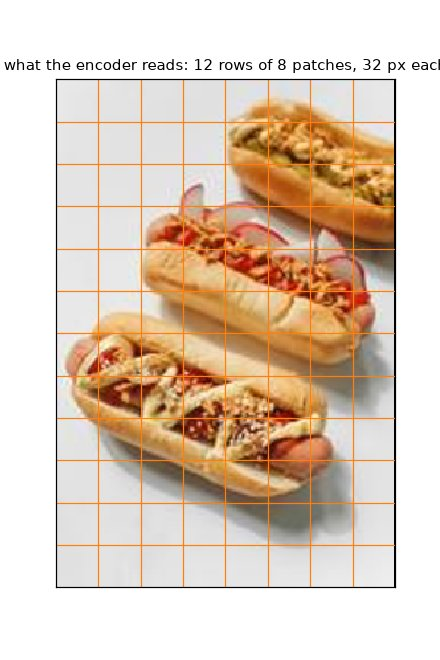

In [ ]:
hdata = TypedDecisions.from_records(htrain, valid=htest, calib=0.2)
torch.manual_seed(0)
hlearn = quiet(decision_learner(hdata, "Hcompany/NeoMME-260M", train="head", image_side=384))
hlearn.show_batch(1)
img, h, w, n = row_image(hlearn)
print(f"{h} rows of {w} patches: {h * w} patches, and {h * w + h + 2} of the row's {n} tokens")
show_grid(img, h, w, title=f"what the encoder reads: {h} rows of {w} patches, 32 px each", fmt="jpeg")

The same three ways to train, with the same settings as for the digits. First the default head:

cached the anchors and trained in 10 s; temperatures {'noul': 5.0, 'noul:2': 5.0}


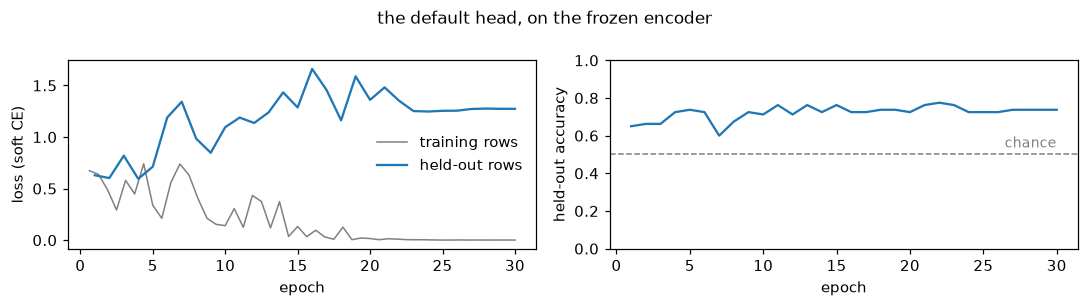

{'accuracy': 0.738,
 'soft_accuracy': 0.687,
 'brier': 0.333,
 'ece': 0.13,
 'n': 80}

In [ ]:
t0 = time.time()
hlearn.fit_one_cycle(30, lr=1e-3)
print(f"cached the anchors and trained in {time.time() - t0:.0f} s; temperatures {hlearn.temperatures}")
hq = htest[0]["questions"]
hanswers = {"default head": hlearn.decider().predict_batch([r["state"] for r in htest], hq)}
plot_history(hlearn, "the default head, on the frozen encoder", chance=0.5)
metrics(hlearn)

Then the linear head, and the probe on the image vectors, as for the digits:

In [ ]:
torch.manual_seed(0)
hlin = quiet(decision_learner(hdata, "Hcompany/NeoMME-260M", train="head", head="linear", image_side=384))
print(hlin.fit_linear())
hanswers["linear head"] = hlin.decider().predict_batch([r["state"] for r in htest], hq)
print(metrics(hlin))
(Xa, ya), (Xb, yb), (Xv, yv) = (image_vectors(hlin, s) for s in ("train", "calib", "valid"))
probes["hot dog"] = probe(torch.cat([Xa, Xb]), torch.cat([ya, yb]), Xv, yv)
print(f"the probe on NeoMME's image vectors: {probes['hot dog']:.2f}")
del hlearn, hlin; release()

{'train_loss': 0.009446114301681519, 'seconds': 0.17}
{'accuracy': 0.7, 'soft_accuracy': 0.634, 'brier': 0.36, 'ece': 0.086, 'n': 80}
the probe on NeoMME's image vectors: 0.71


And LoRA, 20 epochs at 10⁻³:

trained in 176 s; temperatures {'noul': 5.0, 'noul:2': 5.0}


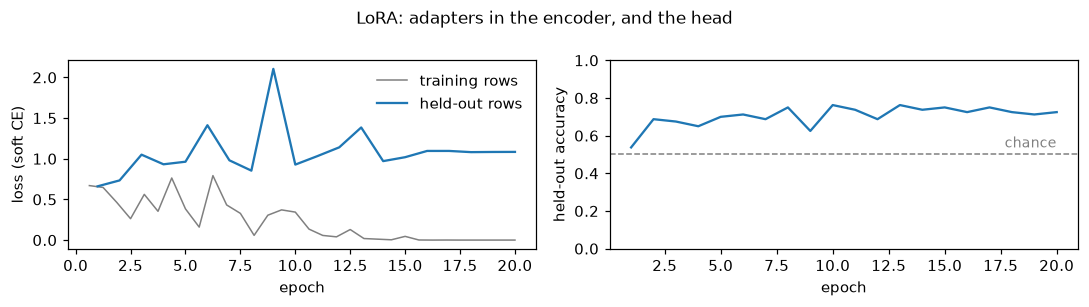

{'accuracy': 0.725,
 'soft_accuracy': 0.702,
 'brier': 0.307,
 'ece': 0.102,
 'n': 80}

In [ ]:
torch.manual_seed(0)
hlora = quiet(decision_learner(hdata, "Hcompany/NeoMME-260M", train="lora", image_side=384))
t0 = time.time(); hlora.fit_one_cycle(20, lr=1e-3)
print(f"trained in {time.time() - t0:.0f} s; temperatures {hlora.temperatures}")
hanswers["LoRA"] = hlora.decider().predict_batch([r["state"] for r in htest], hq)
plot_history(hlora, "LoRA: adapters in the encoder, and the head", chance=0.5)
metrics(hlora)

In [ ]:
del hlora; release()

### The answers

A noul's answer is a single number, `noul`: the probability that the statement is true. The cards below show it as two bars, *hot dog* and *not hot dog*, for the default head on the first four test photos of each class:

{
 "hot_dog": {
  "type": "noul",
  "noul": 0.8999,
  "confidence": 0.8999,
  "answer_confidence": 0.8999
 }
}


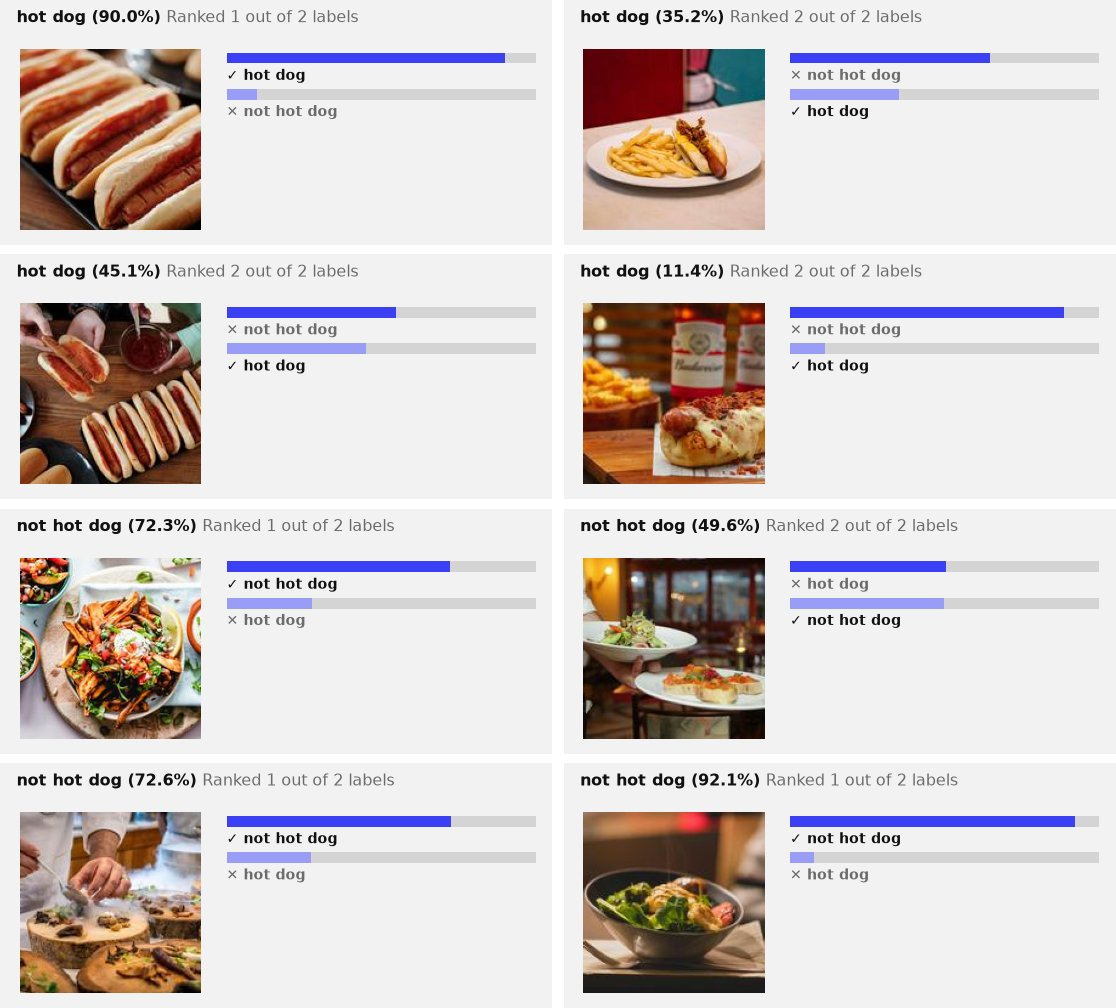

In [ ]:
print(json.dumps(hanswers["default head"][0], indent=1))
label = lambda truth: "hot dog" if truth else "not hot dog"
def hotdog_cards(answers, recs):
    "A card per record: its photo, its gold class, and the two classes' probabilities"
    return [{"image": r["state"]["image"], "gold": label(r["gold"]["hot_dog"]["noul"]),
             "probs": {"hot dog": a["hot_dog"]["noul"], "not hot dog": round(1 - a["hot_dog"]["noul"], 4)}} for a, r in zip(answers, recs)]

pick = [i for i, r in enumerate(htest) if r["gold"]["hot_dog"]["noul"] == 1][:4] + [i for i, r in enumerate(htest) if r["gold"]["hot_dog"]["noul"] == 0][:4]
show_cards(hotdog_cards([hanswers["default head"][i] for i in pick], [htest[i] for i in pick]), top=2, fmt="jpeg")

Across all 80 test photos, the probability each model gave *hot dog*, split by what the photo shows. An answer of 0.5 or more reads as *hot dog*, so an answer is right on its class's side of the dashed line:

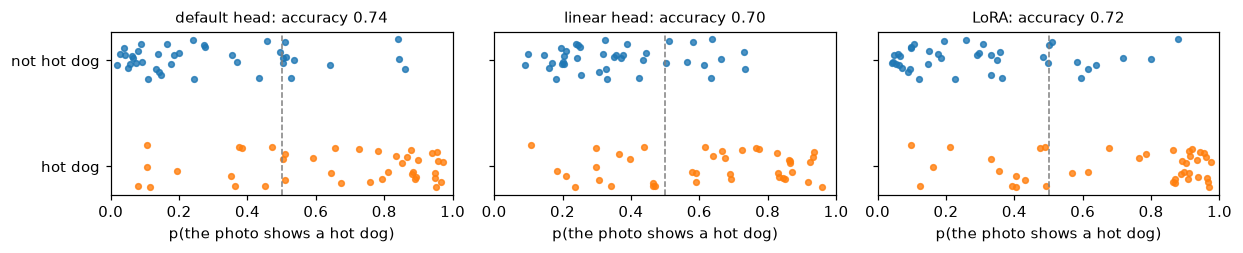

In [ ]:
#| code-fold: true
#| code-summary: figure code
truth = [r["gold"]["hot_dog"]["noul"] for r in htest]
fig, axs = plt.subplots(1, len(hanswers), figsize=(3.8 * len(hanswers), 2.4), sharey=True)
jitter = np.random.default_rng(0).uniform(-0.2, 0.2, len(htest))
for ax, (name, ans) in zip(axs, hanswers.items()):
    p = np.array([a["hot_dog"]["noul"] for a in ans])
    for k, (t, col) in enumerate(((1.0, "C1"), (0.0, "C0"))):
        sel = np.array(truth) == t
        ax.scatter(p[sel], k + jitter[sel], s=14, color=col, alpha=0.8)
    ax.axvline(0.5, color="gray", ls="--", lw=1)
    ax.set(xlim=(0, 1), yticks=[0, 1], xlabel="p(the photo shows a hot dog)"); ax.set_yticklabels(["hot dog", "not hot dog"])
    ax.set_title(f"{name}: accuracy {np.mean((p >= 0.5) == (np.array(truth) == 1)):.2f}", fontsize=10)
plt.tight_layout(); plt.show()

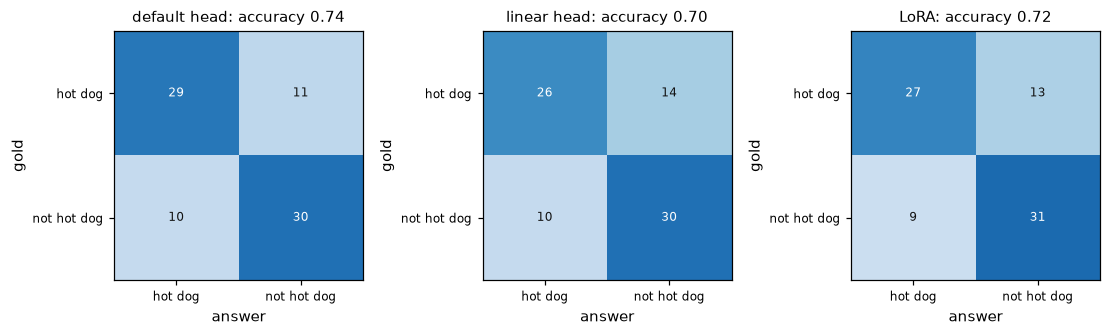

In [ ]:
plot_confusion({name: ([label(t) for t in truth], [label(a["hot_dog"]["noul"] >= 0.5) for a in ans]) for name, ans in hanswers.items()},
               ["hot dog", "not hot dog"])

Most photos land on the right side of 0.5. The mistakes are mostly hot dogs the models doubt (11 of the 40 for the default head). The default head and LoRA are also sure of a few wrong ones, giving two or three other photos more than 0.8. The training curves above show the models growing overconfident: the training loss goes to zero while the held-out loss climbs. The temperatures fitted on the 16 calib photos stop at sysone's upper bound, 5, for both the default head and LoRA.

### Photos from the same shoot

Stock photos come in series: several shots of one scene, whose file names are nearly consecutive numbers. The seeded split doesn't know about them, so some held-out photos have a sibling from the same shoot among the training photos. The top row below is held-out photos, and the bottom row is the training photo whose number is closest:

17 of the 40 held-out hot dogs, and 1 of the 40 other photos, have a training photo within 10 numbers of theirs


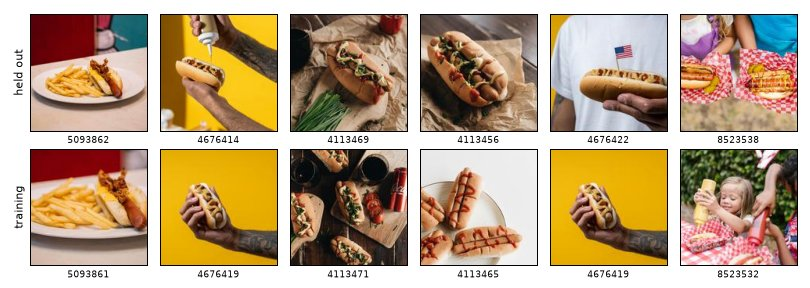

In [ ]:
num = lambda r: int(r["id"].split("-")[1])                       # the photo's file name, a number
sibling = np.array([min(abs(num(r) - num(s)) for s in htrain) <= 10 for r in htest])
hot = np.array(truth) == 1
print(f"{(sibling & hot).sum()} of the {hot.sum()} held-out hot dogs, and {(sibling & ~hot).sum()} of the {(~hot).sum()} other photos, "
      "have a training photo within 10 numbers of theirs")
pairs = [(r, min(htrain, key=lambda s: abs(num(r) - num(s)))) for r, s in zip(htest, sibling) if s][:6]
fig, axs = plt.subplots(2, len(pairs), figsize=(1.5 * len(pairs), 3.2))
for k, (r, s) in enumerate(pairs):
    for row, x in enumerate((r, s)):
        axs[row, k].imshow(square(PILImage.open(x["state"]["image"]))); axs[row, k].set_xticks([]); axs[row, k].set_yticks([])
        axs[row, k].set_xlabel(x["id"].split("-")[1], fontsize=7)
axs[0, 0].set_ylabel("held out", fontsize=9); axs[1, 0].set_ylabel("training", fontsize=9)
plt.tight_layout(); show_figure(fig, "jpeg")

In [ ]:
right = {name: (np.array([a["hot_dog"]["noul"] for a in ans]) >= 0.5) == hot for name, ans in hanswers.items()}
pd.DataFrame({name: {f"hot dogs with a sibling in training ({(sibling & hot).sum()})": r[sibling & hot].mean(),
                     f"hot dogs without one ({(~sibling & hot).sum()})": r[~sibling & hot].mean(),
                     f"other photos ({(~hot).sum()})": r[~hot].mean()} for name, r in right.items()}).round(2)

,default head,linear head,LoRA
hot dogs with a sibling in training (17),0.76,0.76,0.76
hot dogs without one (23),0.70,0.57,0.61
other photos (40),0.75,0.75,0.78


All three models find more of the hot dogs that have a sibling in training (0.76) than of those that don't (0.57 to 0.70). The groups are small, 17 and 23 photos, so each rate is only known to about ±0.1, but the gap goes the same way for every model. So the accuracies above flatter the task a little. An honest split would put a whole shoot on one side, just as sysone splits by case rather than by row (see [data](../02_data.ipynb#splits-by-case)).

## Both tasks side by side

In [ ]:
def summary(answers, recs, qs):
    "Accuracy, Brier score and ECE of each model's answers"
    return pd.DataFrame({name: {k: v for k, v in answer_metrics([(qs, a, r["gold"]) for a, r in zip(ans, recs)]).items()
                                if k in ("accuracy", "brier", "ece")} for name, ans in answers.items()}).T

results = pd.concat({"digits": summary(answers, test, q), "hot dog": summary(hanswers, htest, hq)}).round(3)
results

accuracy  brier    ece
digits  default head     0.310  0.780  0.112
        linear head      0.410  0.721  0.169
        LoRA             0.330  0.787  0.105
hot dog default head     0.738  0.333  0.130
        linear head      0.700  0.360  0.086
        LoRA             0.725  0.307  0.102

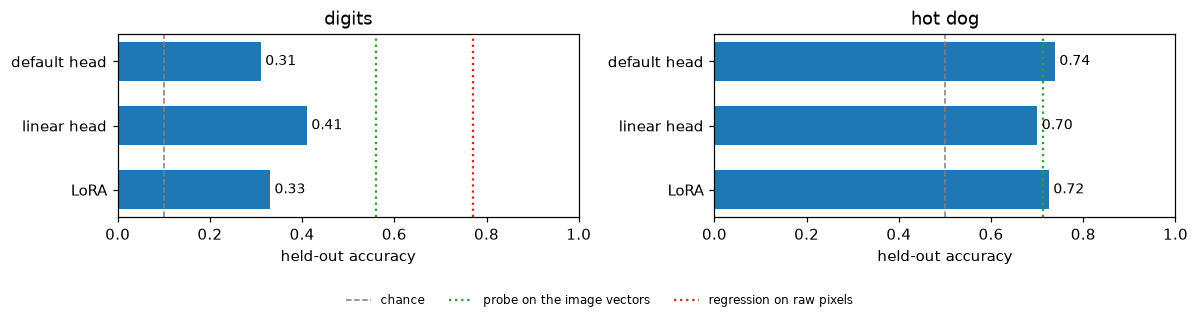

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, axs = plt.subplots(1, 2, figsize=(11, 2.9))
for ax, (task, chance) in zip(axs, (("digits", 0.1), ("hot dog", 0.5))):
    r = results.loc[task, "accuracy"][::-1]
    ax.barh(r.index, r.values, color="C0", height=0.6)
    for i, v in enumerate(r.values): ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)
    ax.axvline(chance, color="gray", ls="--", lw=1, label="chance")
    ax.axvline(probes[task], color="C2", ls=":", lw=1.5, label="probe on the image vectors")
    if task == "digits": ax.axvline(pixel_probe, color="C3", ls=":", lw=1.5, label="regression on raw pixels")
    ax.set(xlim=(0, 1), title=task, xlabel="held-out accuracy")
fig.legend(*axs[0].get_legend_handles_labels(), loc="lower center", ncol=3, fontsize=8, frameon=False)
plt.tight_layout(rect=(0, 0.1, 1, 1)); plt.show()

On neither task does LoRA beat the best head on the frozen encoder, and the heads train in seconds from cached anchors where LoRA takes minutes. So the application's default, a frozen encoder with cached anchors, is the right first thing to try. Which head wins depends on the task: the linear head by 0.10 on the digits, about two standard errors, and the default head by 0.04 on the photos, less than one. The probe shows how much the image vectors hold: on the digits more than any model reads from the anchors, on the photos about what the heads reach.

## One more setting: the image size

`image_side` sets how many patches the encoder gets. At 32 pixels a patch, a side of 224 gives 7 patches along it and 448 gives 14. The runs above used 224 for the digits and 384 for the photos, the sizes of the earlier runs in the multimodal notebook. Both heads train in seconds from cached anchors, so a sweep over sizes is cheap. The encoder caches the anchors afresh for every size, since the cache key includes the transform:

In [ ]:
sweep = {"digits": (train, test, (56, 84, 112, 140, 168, 224, 448)), "hot dog": (htrain, htest, (96, 128, 160, 224, 320, 384, 512))}
t0, sizes = time.time(), {}
for task, (tr, te, sides) in sweep.items():
    for side in sides:
        row = {}
        for head in ("linear", None):
            torch.manual_seed(0)
            l = quiet(decision_learner(TypedDecisions.from_records(tr, valid=te, calib=0.2), "Hcompany/NeoMME-260M", train="head",
                                       head=head, image_side=side))
            if head == "linear": l.fit_linear()
            else: l.fit_one_cycle(30, lr=1e-3)
            row["linear head" if head else "default head"] = round(l.validate()["accuracy"], 3)
            _, h, w, n = row_image(l)
            del l; release()
        sizes[(task, side)] = {"patches (first row)": f"{h} × {w}", "tokens per row": n, **row}
sizes = pd.DataFrame(sizes).T
print(f"{2 * len(sizes)} learners in {time.time() - t0:.0f} s")
sizes

28 learners in 153 s


patches (first row) tokens per row linear head default head
digits  56                2 × 2             50        0.54         0.57
        84                3 × 3             56        0.48         0.48
        112               4 × 4             64        0.57         0.35
        140               5 × 5             74        0.44         0.37
        168               6 × 6             86        0.41         0.32
        224               7 × 7            100        0.41         0.31
        448             14 × 14            254         0.5         0.35
hot dog 96                3 × 2             40         0.6        0.675
        128               4 × 3             47       0.662        0.688
        160               5 × 4             56       0.713        0.675
        224               7 × 5             73       0.775         0.75
        320              10 × 7            111       0.675        0.775
        384              12 × 8            139         0.7        0.738
        512             16 × 11            223       0.762          0.8

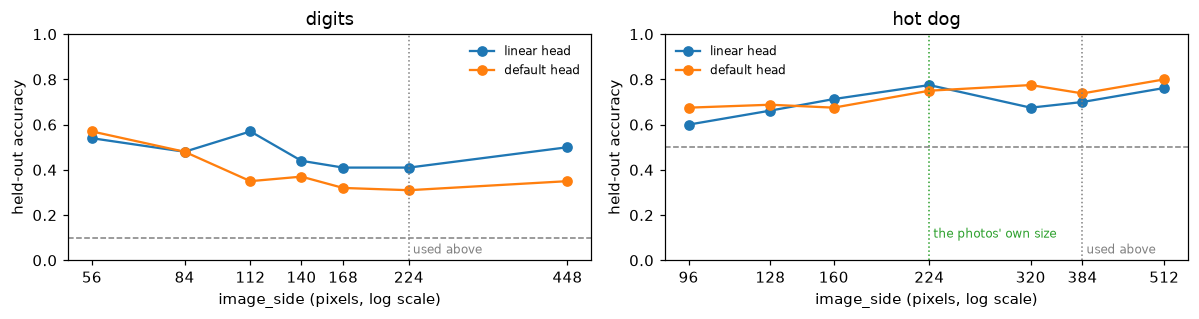

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, axs = plt.subplots(1, 2, figsize=(11, 3))
for ax, (task, used, chance) in zip(axs, (("digits", 224, 0.1), ("hot dog", 384, 0.5))):
    s = sizes.loc[task]
    for col, c in (("linear head", "C0"), ("default head", "C1")): ax.plot(s.index, s[col].astype(float), "o-", color=c, label=col, lw=1.5)
    ax.axvline(used, color="gray", ls=":", lw=1); ax.text(used, 0.03, " used above", color="gray", fontsize=8)
    if task == "hot dog": ax.axvline(224, color="C2", ls=":", lw=1); ax.text(224, 0.1, " the photos' own size", color="C2", fontsize=8)
    ax.axhline(chance, color="gray", ls="--", lw=1)
    ax.set(xscale="log", ylim=(0, 1), xlabel="image_side (pixels, log scale)", ylabel="held-out accuracy", title=task)
    ax.set_xticks(list(s.index)); ax.set_xticklabels([str(v) for v in s.index]); ax.minorticks_off(); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

The two tasks respond differently.

- **The digits read best small.** At 56 to 112 pixels (2 × 2 to 4 × 4 patches) the linear head reaches 0.54 to 0.57, against 0.41 at 224, and the default head reaches 0.57 at 56. One reading: NeoMME was trained on pages, whose characters are a fraction of a patch, and a digit shrunk to 56 pixels is closer to that than one enlarged to 224.
- **The photos lose accuracy below their own 224 pixels** (0.60 to 0.71 at 96 to 160) and gain nothing clear above it. From 224 to 512 both heads stay between 0.68 and 0.80, with no trend.

These sizes were compared on the test split, which flatters the best of them. Choosing an `image_side` for real takes a validation split of its own. Here is the linear head at 112 pixels on the same ten test digits as before:

{'accuracy': 0.57, 'soft_accuracy': 0.334, 'brier': 0.637, 'ece': 0.188, 'n': 100}


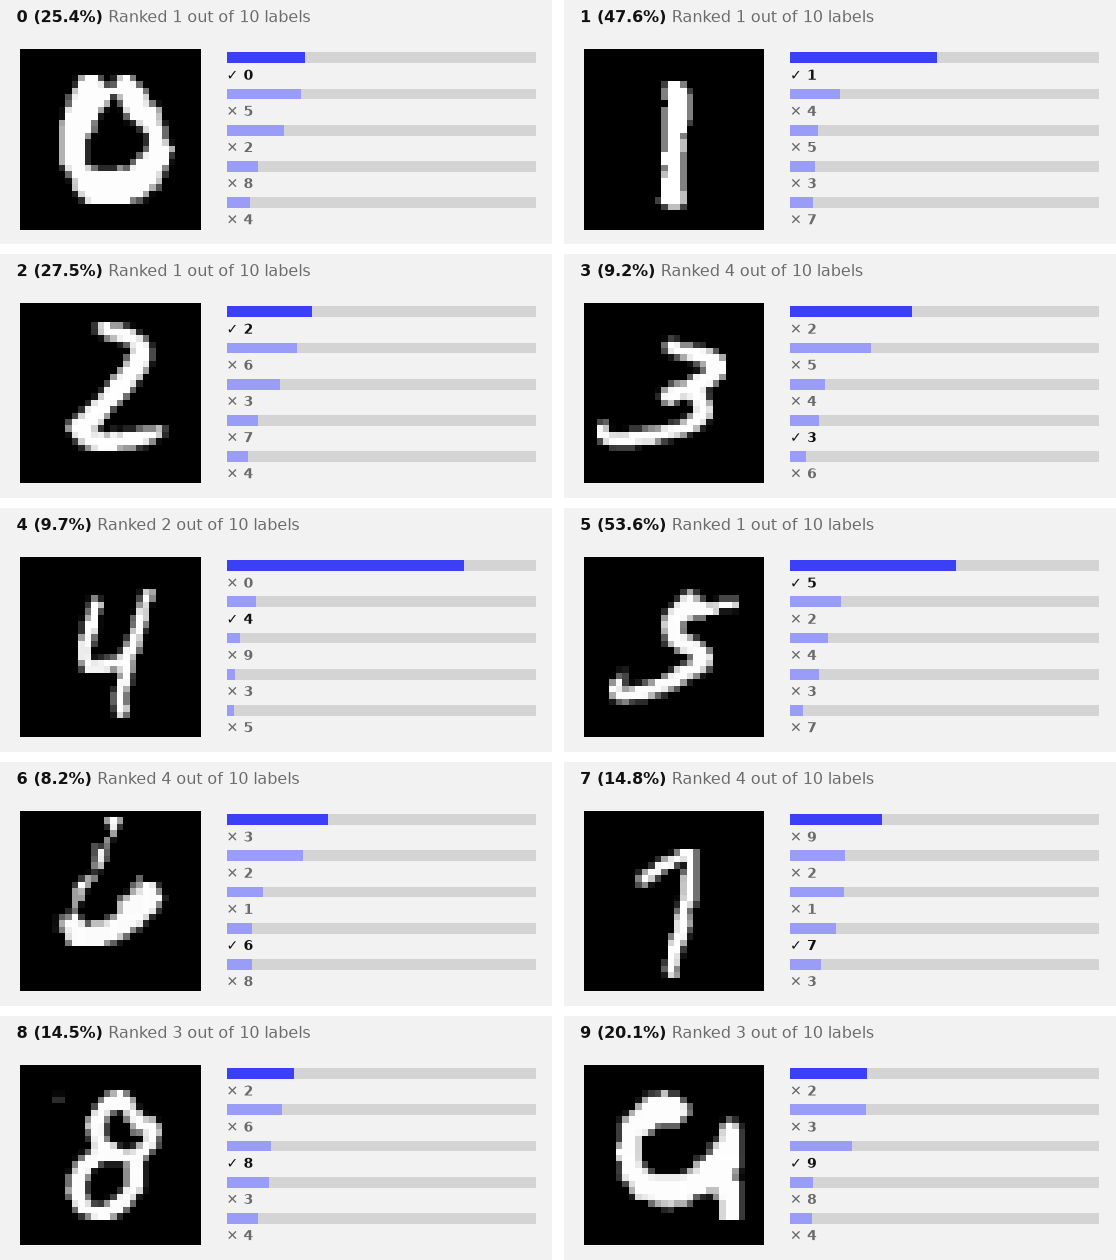

In [ ]:
torch.manual_seed(0)
small = quiet(decision_learner(TypedDecisions.from_records(train, valid=test, calib=0.2), "Hcompany/NeoMME-260M", train="head",
                               head="linear", image_side=112))
small.fit_linear()
print(metrics(small))
small_answers = small.decider().predict_batch([r["state"] for r in test], q)
show_cards(digit_cards([small_answers[i] for i in firsts], [test[i] for i in firsts]))
del small; release()

At 112 pixels the linear head gets four of the ten right, the 0, 1, 2 and 5, where the default head at 224 got two. The 9 it read as a 0 is now its third guess.

## With Kaggle's photos

The hot-dog task was set on Kaggle's [dansbecker/hot-dog-not-hot-dog](https://www.kaggle.com/datasets/dansbecker/hot-dog-not-hot-dog), which needs a Kaggle account. With one, log in to the Kaggle CLI (`pip install kaggle`, then `kaggle auth login`), download the dataset, and point `hotdog_records` at its folder. It looks for a `train` folder that holds one folder per class, named `hotdog` and `not_hotdog`, with or without underscores between the words:

In [ ]:
#| eval: false
# kaggle datasets download dansbecker/hot-dog-not-hot-dog -p hot-dog-not-hot-dog --unzip
htrain, htest = hotdog_records(src="hot-dog-not-hot-dog", dest=data_dir / "hotdog-kaggle")

Everything after that runs as above.

In [ ]:
print(f"the whole notebook: {(time.time() - t_start) / 60:.1f} minutes")

the whole notebook: 9.1 minutes
